## GitHub Repository

The complete source code, tutorial materials, and project files are available here:

🔗 **Project Repository:**  
https://github.com/gurralalaxminarasimha/MachineLearning-Project

TensorFlow version: 2.20.0
Downloaded path: /root/.keras/datasets/flower_photos_extracted

Correct dataset directory: /root/.keras/datasets/flower_photos_extracted/flower_photos
Class folders found:
- daisy
- dandelion
- roses
- sunflowers
- tulips
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.

Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5

Fast tutorial subset ready.
Training batches used: 16
Validation batches used: 6


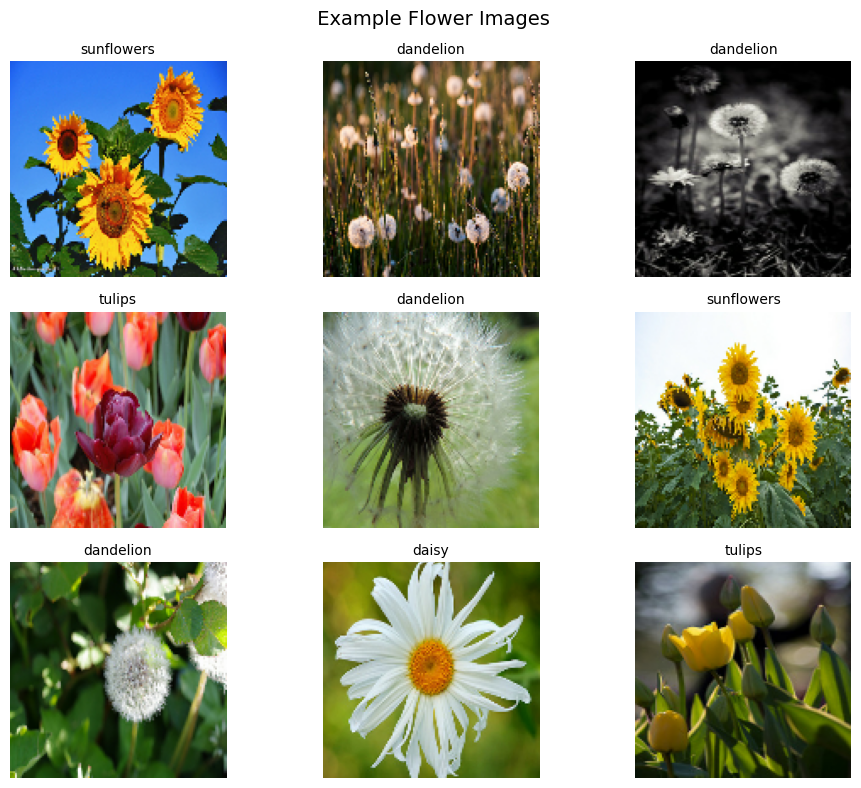

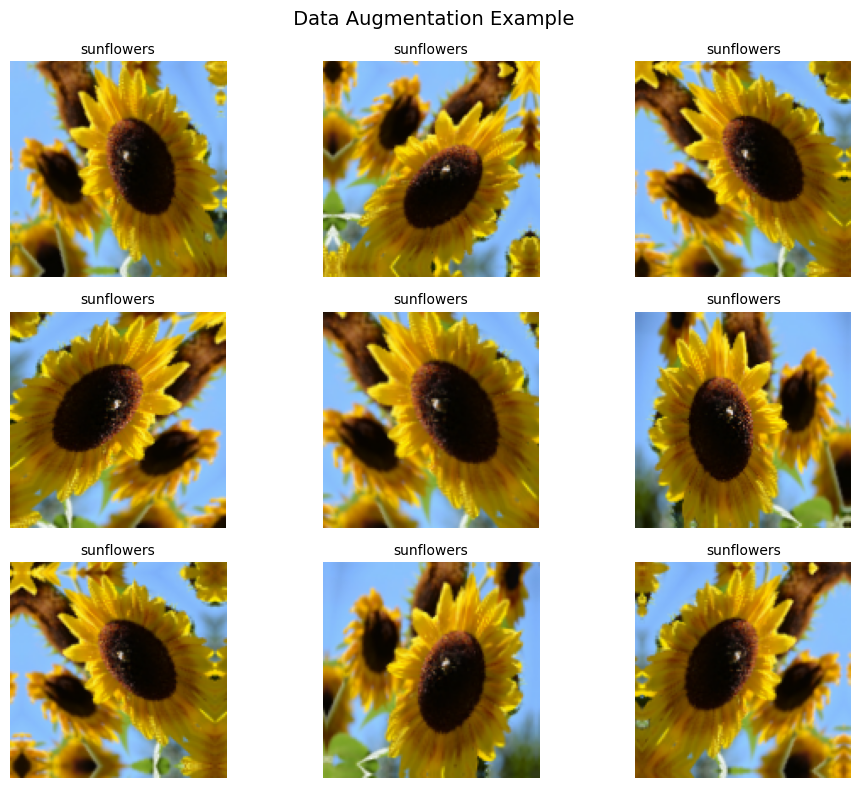


Training small CNN from scratch...
Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 493ms/step - accuracy: 0.1816 - loss: 1.6060 - val_accuracy: 0.2396 - val_loss: 1.5960
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - accuracy: 0.2246 - loss: 1.5912 - val_accuracy: 0.2448 - val_loss: 1.5760

Training MobileNetV2 transfer learning model...
Epoch 1/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 551ms/step - accuracy: 0.3164 - loss: 1.7258 - val_accuracy: 0.5990 - val_loss: 1.0665
Epoch 2/2
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step - accuracy: 0.5918 - loss: 0.9848 - val_accuracy: 0.7500 - val_loss: 0.7054


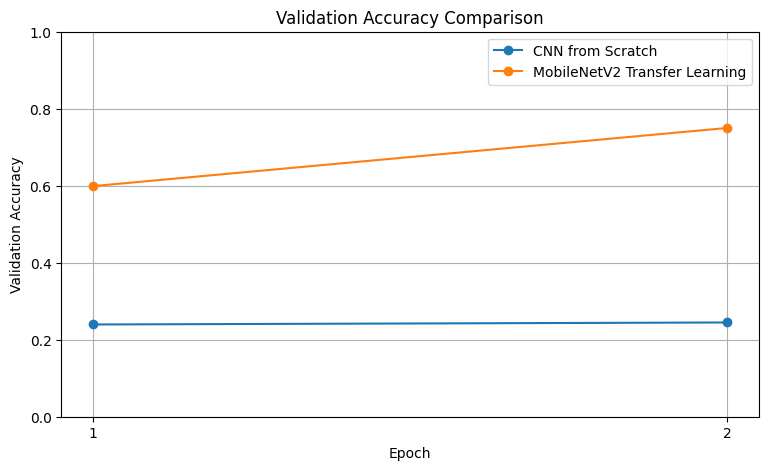

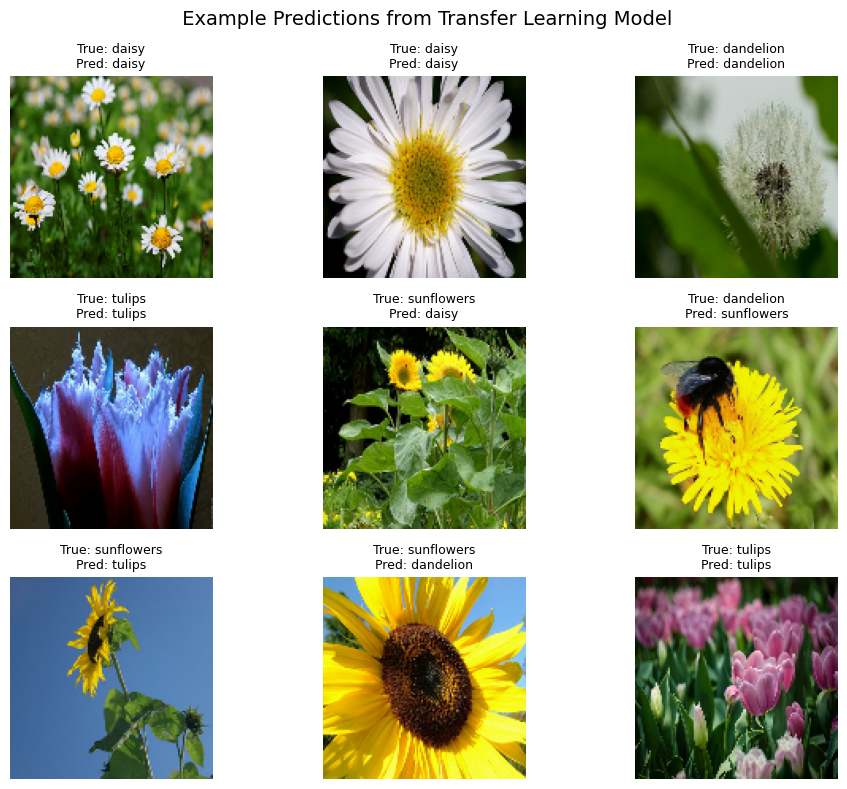


================ FINAL TUTORIAL COMPARISON ================
CNN from Scratch Final Validation Accuracy: 0.2448
MobileNetV2 Transfer Learning Final Validation Accuracy: 0.75

Figures saved in: figures


In [2]:
# ============================================================
# FAST TUTORIAL CODE:
# Transfer Learning with MobileNetV2 for Flower Classification
# ============================================================
# This code is designed for tutorial explanation, not a full project.
# It uses a small subset of the dataset so training finishes faster.
# ============================================================

import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# -----------------------------
# 1. Basic settings
# -----------------------------

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 128          # smaller image size = faster training
BATCH_SIZE = 32
EPOCHS = 2             # small number of epochs for tutorial speed
TRAIN_BATCHES = 16     # 16 batches x 32 = 512 training images
VAL_BATCHES = 6        # 6 batches x 32 = 192 validation images

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)


# -----------------------------
# 2. Download and find correct dataset folder
# -----------------------------

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

downloaded_path = tf.keras.utils.get_file(
    fname="flower_photos.tgz",
    origin=dataset_url,
    untar=True
)

downloaded_path = pathlib.Path(downloaded_path)
print("Downloaded path:", downloaded_path)

expected_classes = {"daisy", "dandelion", "roses", "sunflowers", "tulips"}

# Search possible folders to avoid the earlier one-class error
search_roots = [
    downloaded_path,
    downloaded_path.parent,
    pathlib.Path.home() / ".keras" / "datasets"
]

data_dir = None

for root in search_roots:
    if root.exists():
        for path in [root] + list(root.rglob("*")):
            if path.is_dir():
                folder_names = {folder.name for folder in path.iterdir() if folder.is_dir()}
                if expected_classes.issubset(folder_names):
                    data_dir = path
                    break
    if data_dir is not None:
        break

if data_dir is None:
    raise FileNotFoundError("Could not find daisy, dandelion, roses, sunflowers and tulips folders.")

print("\nCorrect dataset directory:", data_dir)
print("Class folders found:")
for folder in sorted(data_dir.iterdir()):
    if folder.is_dir():
        print("-", folder.name)


# -----------------------------
# 3. Create training and validation datasets
# -----------------------------

train_full = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_full = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_full.class_names
num_classes = len(class_names)

print("\nClasses:", class_names)
print("Number of classes:", num_classes)

# Safety check
assert num_classes == 5, "Dataset loading is wrong. It should show 5 flower classes."

# Use only a small subset for fast tutorial demonstration
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_full.take(TRAIN_BATCHES).cache().prefetch(AUTOTUNE)
val_ds = val_full.take(VAL_BATCHES).cache().prefetch(AUTOTUNE)

print("\nFast tutorial subset ready.")
print("Training batches used:", TRAIN_BATCHES)
print("Validation batches used:", VAL_BATCHES)


# -----------------------------
# 4. Figure 1: Show example flower images
# -----------------------------

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])], fontsize=10)
        plt.axis("off")

plt.suptitle(" Example Flower Images", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_1_sample_images.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 5. Figure 2: Data augmentation example
# -----------------------------

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15)
])

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    image = images[0]
    label = class_names[int(labels[0])]

    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(image, 0), training=True)

        plt.subplot(3, 3, i + 1)
        plt.imshow(tf.cast(augmented_image[0], tf.uint8))
        plt.title(label, fontsize=10)
        plt.axis("off")

plt.suptitle(" Data Augmentation Example", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_2_data_augmentation.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 6. Build and train small CNN from scratch
# -----------------------------

baseline_cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(16, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining small CNN from scratch...")
baseline_history = baseline_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


# -----------------------------
# 7. Build and train MobileNetV2 transfer learning model
# -----------------------------

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    alpha=0.35          # smaller MobileNetV2 = faster training
)

base_model.trainable = False

transfer_model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(num_classes, activation="softmax")
])

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nTraining MobileNetV2 transfer learning model...")
transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


# -----------------------------
# 8. Figure 3: Compare validation accuracy
# -----------------------------

baseline_val_acc = baseline_history.history["val_accuracy"]
transfer_val_acc = transfer_history.history["val_accuracy"]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(9, 5))

plt.plot(epochs_range, baseline_val_acc, marker="o", label="CNN from Scratch")
plt.plot(epochs_range, transfer_val_acc, marker="o", label="MobileNetV2 Transfer Learning")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(list(epochs_range))
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.savefig("figures/figure_3_validation_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 9. Figure 4: Example predictions
# -----------------------------

plt.figure(figsize=(10, 8))

for images, labels in val_ds.take(1):
    predictions = transfer_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(9):
        true_name = class_names[int(labels[i])]
        predicted_name = class_names[int(predicted_labels[i])]

        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"True: {true_name}\nPred: {predicted_name}", fontsize=9)
        plt.axis("off")

plt.suptitle(" Example Predictions from Transfer Learning Model", fontsize=14)
plt.tight_layout()
plt.savefig("figures/figure_4_prediction_examples.png", dpi=300, bbox_inches="tight")
plt.show()


# -----------------------------
# 10. Print simple final result
# -----------------------------

baseline_final_acc = baseline_val_acc[-1]
transfer_final_acc = transfer_val_acc[-1]

print("\n================ FINAL TUTORIAL COMPARISON ================")
print("CNN from Scratch Final Validation Accuracy:", round(baseline_final_acc, 4))
print("MobileNetV2 Transfer Learning Final Validation Accuracy:", round(transfer_final_acc, 4))
print("===========================================================")

print("\nFigures saved in:", FIGURE_DIR)